# Day 4 – Fund Performance Analytics

## Objectives
- Calculate Daily Returns
- Calculate CAGR
- Calculate Sharpe Ratio
- Calculate Sortino Ratio
- Calculate Alpha & Beta against NIFTY100
- Calculate Maximum Drawdown
- Generate Fund Scorecard
- Compare Top 5 Funds against NIFTY100 Benchmark

## Deliverables
- alpha_beta.csv
- cagr_results.csv
- fund_scorecard.csv
- benchmark_comparison.png

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

pd.set_option("display.max_columns", None)

## Imports

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

funds = pd.read_csv("../data/raw/01_fund_master.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

## Load Data

In [4]:
print("NAV")
print(nav.head())

print("\nNAV Columns")
print(nav.columns.tolist())

NAV
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639

NAV Columns
['amfi_code', 'date', 'nav']


In [5]:
print("\nBenchmark")
print(benchmark.head())

print("\nBenchmark Columns")
print(benchmark.columns.tolist())


Benchmark
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Benchmark Columns
['date', 'index_name', 'close_value']


In [6]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [7]:
print(nav.dtypes)
print(benchmark.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object
date           datetime64[ns]
index_name             object
close_value           float64
dtype: object


In [8]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

## Daily Returns

In [9]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [10]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


## Daily Return Statistics

In [11]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

## Daily Return Distribution

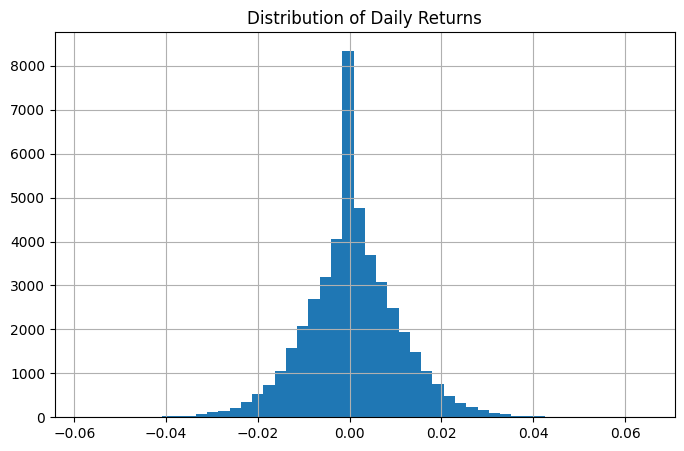

In [13]:
nav["daily_return"].hist(
    bins=50,
    figsize=(8,5)
)

plt.title("Distribution of Daily Returns")

plt.savefig(
    "../reports/charts/daily_returns_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [14]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

##  Benchmark Returns

In [15]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

In [16]:
benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [17]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


#### CAGR

In [18]:
cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] - group.iloc[0]["date"]).days
        / 365.25
    )

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_results.append([
        amfi_code,
        start_nav,
        end_nav,
        years,
        cagr
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "start_nav",
        "end_nav",
        "years",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,start_nav,end_nav,years,cagr
0,100016,520.4608,583.6113,4.399726,0.026371
1,100025,26.3169,31.8843,4.399726,0.044582
2,100033,107.3758,342.0072,4.399726,0.301232
3,101206,305.0996,773.2939,4.399726,0.235384
4,101207,38.5736,53.9836,4.399726,0.079388


In [19]:
cagr_df["cagr"].describe()

count    40.000000
mean      0.167357
std       0.103090
min       0.011717
25%       0.068618
50%       0.166073
75%       0.244883
max       0.328274
Name: cagr, dtype: float64

## Save CAGR

In [20]:
cagr_df.to_csv(
    "../reports/cagr_results.csv",
    index=False
)

## Sharp Ratio

In [21]:
rf=0.065
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_results.append([
        amfi_code,
        annual_return,
        annual_volatility,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "annual_return",
        "annual_volatility",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,annual_return,annual_volatility,sharpe_ratio
0,100016,0.035683,0.145481,-0.201517
1,100025,0.042854,0.039052,-0.567095
2,100033,0.272111,0.189367,1.093699
3,101206,0.214647,0.145682,1.027213
4,101207,0.106962,0.257973,0.162661


In [22]:
sharpe_df["sharpe_ratio"].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: sharpe_ratio, dtype: float64

# Sortino Ratio

In [24]:
sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = (
        downside_returns.std() * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append([
        amfi_code,
        annual_return,
        downside_std,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "annual_return",
        "downside_volatility",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,annual_return,downside_volatility,sortino_ratio
0,100016,0.035683,0.083513,-0.351047
1,100025,0.042854,0.023514,-0.941821
2,100033,0.272111,0.113229,1.829134
3,101206,0.214647,0.083157,1.799563
4,101207,0.106962,0.151683,0.276644


In [25]:
sortino_df["sortino_ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [26]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

# Alpha/Beta

In [27]:
alpha_beta_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 50:
        continue

    slope, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_results.append([
        amfi_code,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [28]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

# Max Drawdown

In [29]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] / running_max
    ) - 1

    max_drawdown = drawdown.min()

    drawdown_results.append([
        amfi_code,
        max_drawdown
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [30]:
drawdown_df["max_drawdown"].describe()

count    40.000000
mean     -0.178729
std       0.112686
min      -0.525742
25%      -0.215927
50%      -0.163070
75%      -0.117653
max      -0.000977
Name: max_drawdown, dtype: float64

In [31]:
alpha_beta_df["beta"].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

# Build Scorecard

In [32]:
scorecard = cagr_df[["amfi_code", "cagr"]]

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

In [33]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown
0,100016,0.026371,-0.201517,0.037476,-0.247344
1,100025,0.044582,-0.567095,0.042818,-0.043083
2,100033,0.301232,1.093699,0.271954,-0.162172
3,101206,0.235384,1.027213,0.213998,-0.112916
4,101207,0.079388,0.162661,0.108971,-0.354469


## Ranks

In [34]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

In [35]:
scorecard["drawdown_rank"] = scorecard[
    "max_drawdown"
].rank(
    ascending=False
)

In [36]:
print(funds.columns.tolist())
print(performance.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [37]:
scorecard = scorecard.merge(
    funds[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

In [38]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,expense_ratio_pct
0,100016,0.026371,-0.201517,0.037476,-0.247344,37.0,35.0,39.0,34.0,1.55
1,100025,0.044582,-0.567095,0.042818,-0.043083,36.0,39.0,38.0,4.0,0.56
2,100033,0.301232,1.093699,0.271954,-0.162172,7.0,7.0,6.0,20.0,1.38
3,101206,0.235384,1.027213,0.213998,-0.112916,12.0,9.0,12.0,9.0,1.60
4,101207,0.079388,0.162661,0.108971,-0.354469,27.0,28.0,27.0,38.0,1.53


In [39]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

In [40]:
scorecard["cagr_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [41]:
scorecard["raw_score"] = (
    0.30 * scorecard["cagr_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

# Convert 0-100

In [42]:
scorecard["score"] = (
    scorecard["raw_score"]
    / scorecard["raw_score"].max()
) * 100

In [44]:
# Final Rank
scorecard["final_rank"] = (
    scorecard["score"]
    .rank(ascending=False)
)

# Sort
scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,expense_ratio_pct,expense_rank,raw_score,score,final_rank
7,102886,0.011717,-0.205832,0.028969,-0.280011,40.0,36.0,40.0,35.0,1.51,24.5,36.175,100.000000,1.0
0,100016,0.026371,-0.201517,0.037476,-0.247344,37.0,35.0,39.0,34.0,1.55,32.0,35.850,99.101589,2.0
17,119095,0.015215,-0.075974,0.048016,-0.516778,39.0,33.0,37.0,39.0,1.38,17.0,33.800,93.434692,3.0
22,119599,0.020545,-0.057187,0.048824,-0.525742,38.0,32.0,36.0,40.0,0.72,5.5,31.425,86.869385,4.0
14,119092,0.063680,0.030785,0.068995,-0.144016,33.0,31.0,30.0,15.0,1.64,39.5,31.075,85.901866,5.0
29,120842,0.067015,0.076000,0.078044,-0.240035,31.0,30.0,29.0,33.0,1.56,33.0,30.850,85.279889,6.0
1,100025,0.044582,-0.567095,0.042818,-0.043083,36.0,39.0,38.0,4.0,0.56,2.0,28.850,79.751209,7.0
4,101207,0.079388,0.162661,0.108971,-0.354469,27.0,28.0,27.0,38.0,1.53,28.5,28.575,78.991016,8.0
5,101208,0.065090,-0.815567,0.060861,-0.001622,32.0,40.0,33.0,3.0,0.79,11.0,28.150,77.816171,9.0
18,119120,0.058894,-0.226575,0.056209,-0.043287,34.0,37.0,34.0,5.0,0.77,9.0,28.100,77.677954,10.0


In [45]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

## Benchmark Comparison Chart

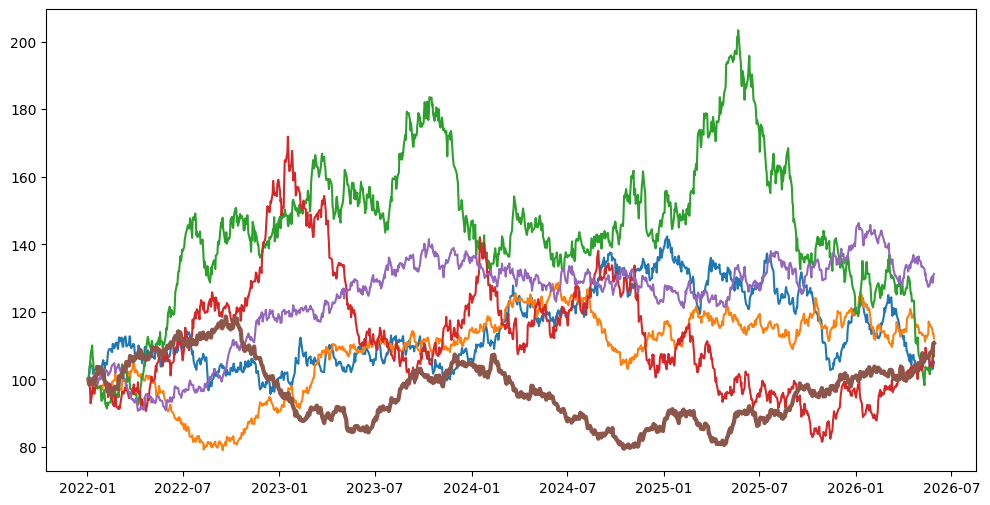

In [46]:
top5 = scorecard.head(5)["amfi_code"].tolist()

plt.figure(figsize=(12,6))

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    normalized = (
        fund_data["nav"]
        / fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        normalized,
        label=str(fund)
    )

    n100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

n100_norm = (
    n100["close_value"]
    / n100["close_value"].iloc[0]
) * 100

plt.plot(
    n100["date"],
    n100_norm,
    linewidth=3,
    label="NIFTY100"
)

C:\Users\PRATEEK\AppData\Local\Temp\ipykernel_22844\2496553419.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


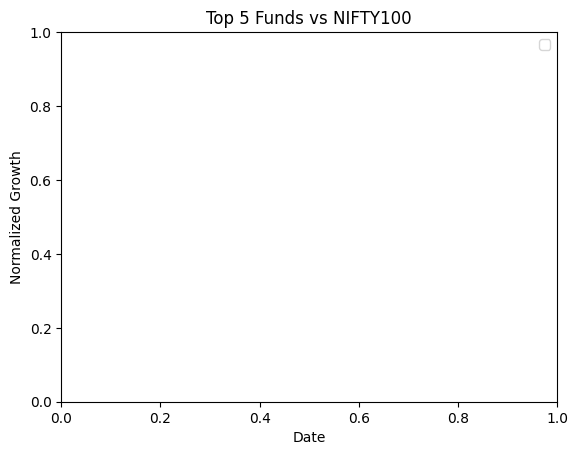

In [47]:
plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Growth")
plt.legend()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()